# 02 · SQL Analysis
Loads the clean data into a DuckDB database and answers the business questions with SQL.

## 4.1 Load the data

In [1]:
%run common.py
con = connect(read_only=False)

In [2]:
%pip install duckdb

Note: you may need to restart the kernel to use updated packages.


In [3]:
import duckdb
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format

con = duckdb.connect('../data/dataco.duckdb')

con.sql("CREATE OR REPLACE TABLE order_items AS SELECT * FROM read_csv_auto('../data/clean/order_items_clean.csv')")
con.sql("CREATE OR REPLACE TABLE orders AS SELECT * FROM read_csv_auto('../data/clean/orders_clean.csv')")

con.sql("SHOW TABLES").df()

,name
0,customers
1,order_items
2,orders
3,products


## 4.2 First queries

In [4]:
con.sql("""
    SELECT COUNT(*) AS items,
           SUM(revenue) AS revenue,
           SUM(item_profit) AS profit
    FROM order_items
""").df()

,items,revenue,profit
0,180519,"33,054,402.38","3,966,902.97"


In [5]:
con.sql("SELECT COUNT(*) AS orders FROM orders").df()

,orders
0,65752


## 4.3 Products table
One row per product, so product details are stored once instead of on every order item.

In [6]:
con.sql("""
    CREATE OR REPLACE TABLE products AS
    SELECT DISTINCT product_id, product_name, category_id, category_name,
                    department_id, department_name, unit_price
    FROM order_items
""")
con.sql("SELECT COUNT(*) AS products FROM products").df()

,products
0,118


## 4.4 Customers table

In [7]:
con.sql("""
    CREATE OR REPLACE TABLE customers AS
    SELECT DISTINCT customer_id, customer_segment, customer_country, customer_state, customer_city
    FROM order_items
""")
con.sql("SELECT COUNT(*) AS customers FROM customers").df()

,customers
0,20652


## 4.5 Test a join
Revenue by department, joining order items to the products table.

In [8]:
con.sql("""
    SELECT p.department_name,
           SUM(i.revenue) AS revenue
    FROM order_items i
    JOIN products p ON i.product_id = p.product_id
    GROUP BY p.department_name
    ORDER BY revenue DESC
""").df()

,department_name,revenue
0,Fan Shop,"15,378,581.71"
1,Apparel,"7,167,654.21"
2,Golf,"4,142,100.96"
3,Footwear,"3,599,468.83"
4,Outdoors,"1,125,953.44"
5,Technology,"933,829.24"
6,Fitness,"357,158.26"
7,Discs Shop,"205,675.90"
8,Health and Beauty,"95,358.11"
9,Pet Shop,"37,318.30"


**Summary:** I loaded the two clean files into DuckDB (order_items: 180,519 rows, orders: 65,752) and checked the totals match what I got in Phase 3. I then split out a products table (118) and a customers table (20,652) so product and customer details are only stored once. I'll join back to them when I need names or categories. Setting it up this way should also make the Power BI model simpler later.

# Phase 5: Explore the data

In [9]:
import matplotlib.pyplot as plt
FIG = '../reports/figures/'

In [10]:
## Chart 1: Orders per month

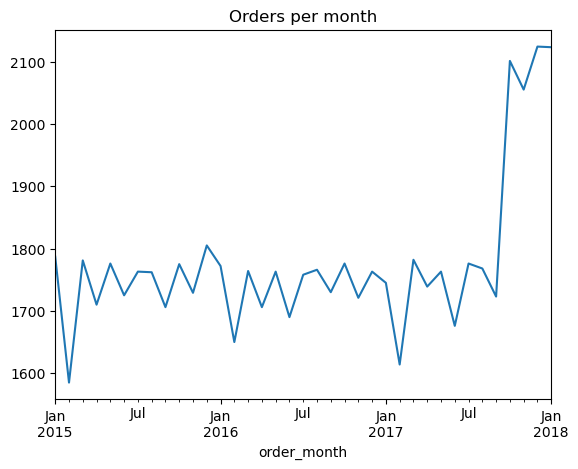

In [11]:
monthly = con.sql("SELECT order_month, COUNT(*) AS orders FROM orders GROUP BY order_month ORDER BY order_month").df()
monthly.plot(x='order_month', y='orders', title='Orders per month', legend=False)
plt.savefig(FIG + 'orders_per_month.png')

## Chart 2: Days to ship

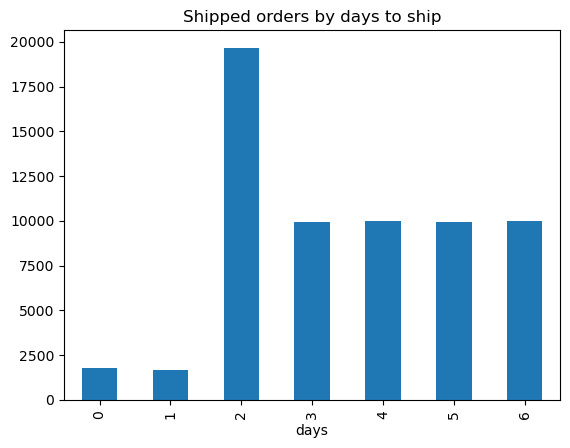

In [12]:
days = con.sql("SELECT days_shipping_real AS days, COUNT(*) AS orders FROM orders WHERE is_shipped GROUP BY days ORDER BY days").df()
days.plot.bar(x='days', y='orders', title='Shipped orders by days to ship', legend=False)
plt.savefig(FIG + 'shipping_days.png')

## Chart 3: Items per discount rate

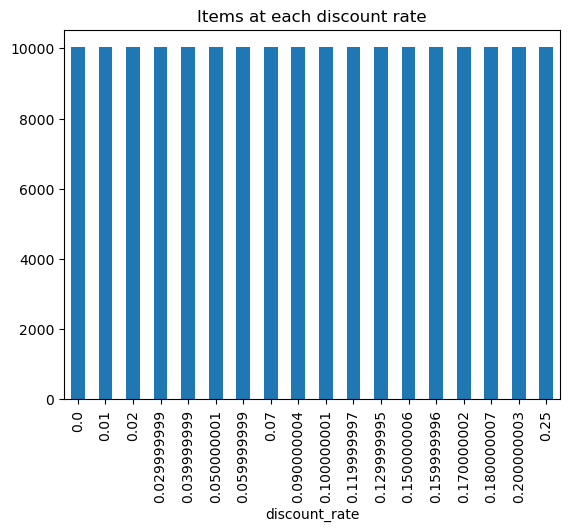

In [13]:
disc = con.sql("SELECT discount_rate, COUNT(*) AS items FROM order_items GROUP BY discount_rate ORDER BY discount_rate").df()
disc.plot.bar(x='discount_rate', y='items', title='Items at each discount rate', legend=False)
plt.savefig(FIG + 'discount_rates.png')

## One number: share of loss-making items

In [14]:
con.sql("SELECT AVG(CASE WHEN is_loss THEN 1 ELSE 0 END) AS loss_share FROM order_items").df()

,loss_share
0,0.19


## What I noticed

- Orders are steady each month, with a jump in late 2017.
- Most orders take 2-6 days to ship, spread very evenly.
- Every discount rate has about the same number of items, which is unusual.
- Roughly 1 in 5 items is sold at a loss.

Next: is lateness linked to shipping mode? Do bigger discounts sell more?

In [15]:
con.close()